In [2]:
from IPython.display import HTML

In [3]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.express as px
import warnings
import nbformat

warnings.filterwarnings('ignore')
sns.set_palette('pastel')
sns.set(style='darkgrid')

In [4]:
df = pd.read_csv('assets\credit_card_fraud_10k.csv')
df.sample(5)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9975,9976,37.10,3,Grocery,0,0,34,3,28,0
9011,9012,82.30,20,Food,1,0,93,3,52,0
788,789,111.58,8,Travel,0,0,60,3,26,0
6801,6802,21.09,3,Grocery,1,0,73,3,21,0
1949,1950,102.46,19,Food,0,0,29,2,41,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [6]:
print(f"No. of duplicated values={df.duplicated().sum()}")

No. of duplicated values=0


In [7]:
num_feat=['transaction_hour','device_trust_score','velocity_last_24h','cardholder_age']

df.describe()[num_feat].T

,count,mean,std,min,25%,50%,75%,max
transaction_hour,10000.0,11.5933,6.922708,0.0,6.0,12.0,18.0,23.0
device_trust_score,10000.0,61.7989,21.487053,25.0,43.0,62.0,80.0,99.0
velocity_last_24h,10000.0,2.0089,1.432559,0.0,1.0,2.0,3.0,9.0
cardholder_age,10000.0,43.4687,14.979147,18.0,30.0,44.0,56.0,69.0


In [8]:
cat_feat=['merchant_category','foreign_transaction','location_mismatch','is_fraud']
for col in cat_feat:
    print(f"Unique Values are {df[col].unique()}")

Unique Values are ['Electronics' 'Travel' 'Grocery' 'Food' 'Clothing']
Unique Values are [0 1]
Unique Values are [0 1]
Unique Values are [0 1]


Dataset is clean and in a good condition. 
There are no null or duplicate values.
One problem is that the dataset is imbalanced as there are more genuine transaction than the fraud ones.

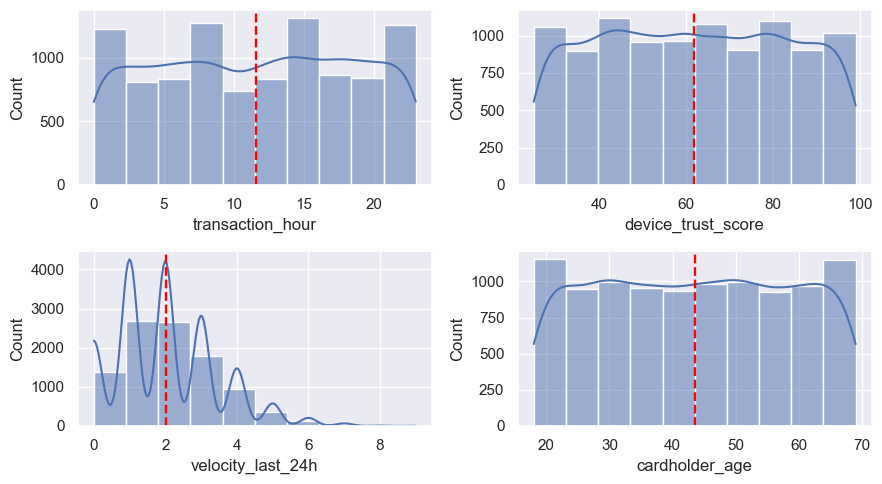

In [9]:
fig,ax=plt.subplots(2,2,figsize=(9,5))
ax=ax.flatten()

for i,col in enumerate(num_feat):
    sns.histplot(x=df[col],kde=True,bins=10,ax=ax[i])
    ax[i].axvline(df[col].mean(),linestyle='--',color='red',linewidth=1.7)
plt.tight_layout()
plt.show()

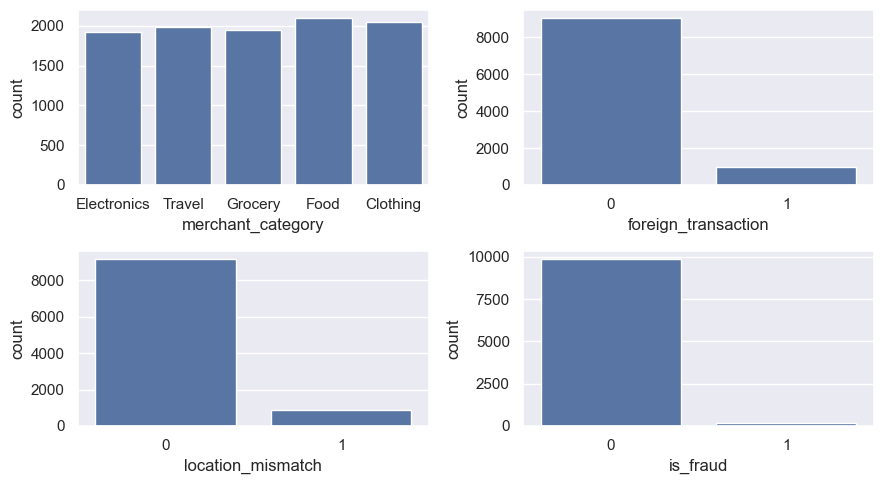

In [10]:
fig,ax=plt.subplots(2,2,figsize=(9,5))
ax=ax.flatten()

for i,col in enumerate(cat_feat):
    sns.countplot(x=df[col],ax=ax[i])
plt.tight_layout()
plt.show()


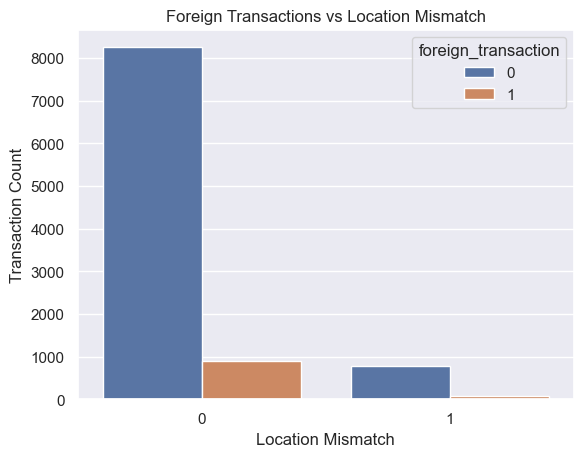

In [11]:
sns.countplot(
    data=df,
    x='location_mismatch',
    hue='foreign_transaction',
)

plt.title('Foreign Transactions vs Location Mismatch')
plt.xlabel('Location Mismatch')
plt.ylabel('Transaction Count')
plt.show()

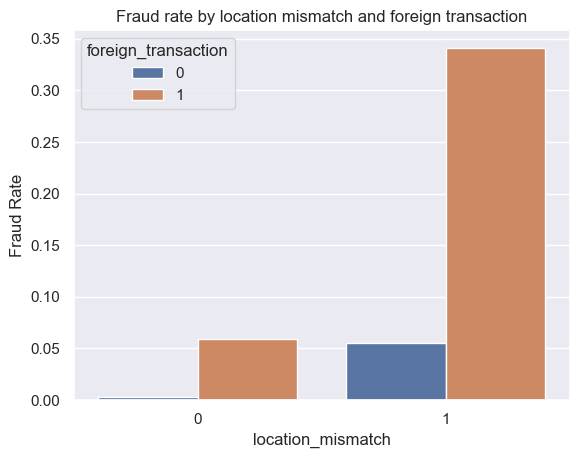

In [12]:
fraud_rate = (
    df.groupby(['location_mismatch', 'foreign_transaction'])['is_fraud'].mean().reset_index()
)

sns.barplot(
    data = fraud_rate,
    x='location_mismatch',
    y='is_fraud',
    hue='foreign_transaction'
)

plt.ylabel('Fraud Rate')
plt.title('Fraud rate by location mismatch and foreign transaction')
plt.show()

In [13]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [14]:
px.pie(data_frame=df, names=df['is_fraud'],height=400 ,width=500).show()

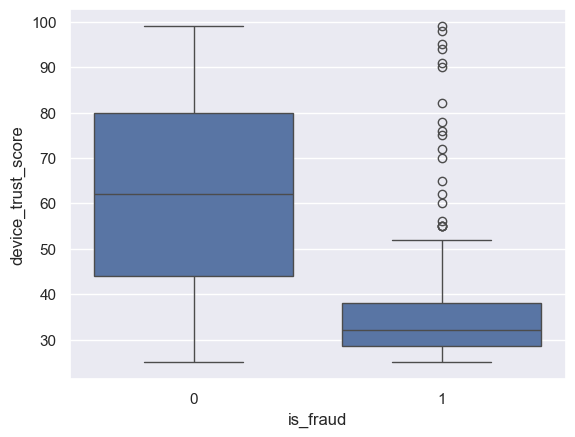

In [15]:
sns.boxplot(x='is_fraud', y='device_trust_score', data=df)
plt.show()

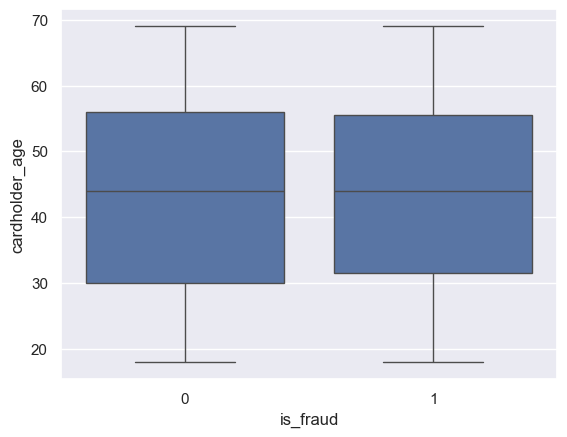

In [16]:
sns.boxplot(data=df,x='is_fraud',y='cardholder_age')
plt.show()

In [17]:
tf=df.groupby('merchant_category',as_index=False)['is_fraud'].count()


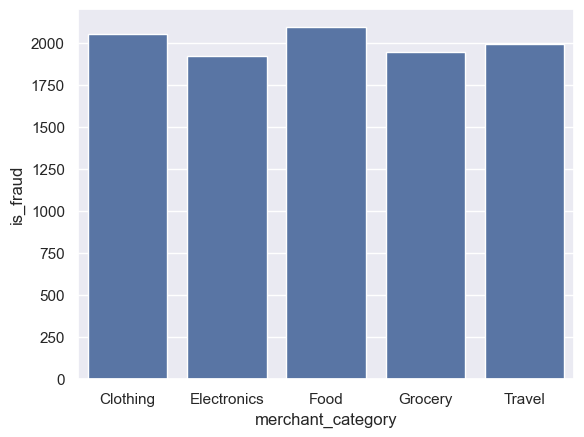

In [18]:
sns.barplot(data=tf, x='merchant_category', y='is_fraud')
plt.show()

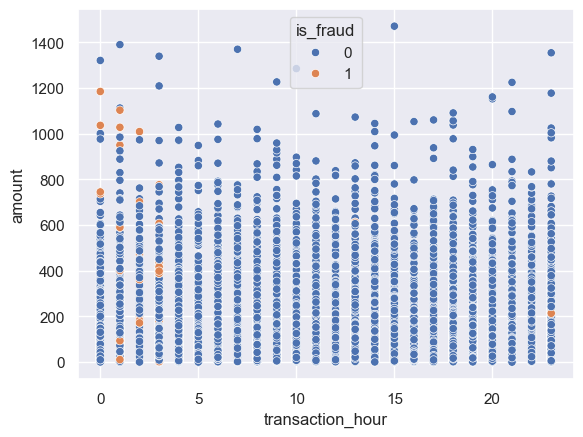

In [19]:
sns.scatterplot(x=df['transaction_hour'],y=df['amount'],hue=df['is_fraud'])
plt.show()

In [20]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix,accuracy_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression ,Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [21]:
X=df.iloc[:,1:-1]
y=df['is_fraud']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)

In [22]:
X_train.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age'],
      dtype='object')

In [23]:
cols=ColumnTransformer([
    ('encode',OrdinalEncoder(),['merchant_category']),
    ('std',StandardScaler(),['amount', 'transaction_hour',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age'])
],
                      remainder='passthrough')

In [24]:
dt = DecisionTreeClassifier(max_depth=7)

pipeline = Pipeline(
    [
        ('preprocess',cols),
        ('mod',dt)
    ]
)

In [25]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('mod', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode', ...), ('std', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

<Axes: xlabel='cols'>

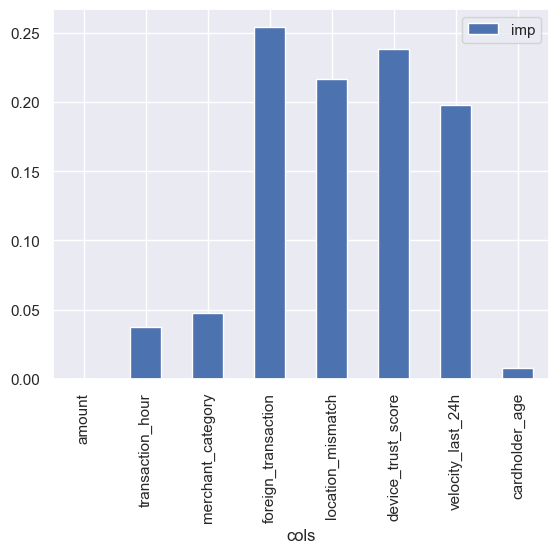

In [26]:
tf=pd.DataFrame({'cols':X_train.columns, 'imp':dt.feature_importances_})

tf.plot(kind='bar',x='cols',y='imp')

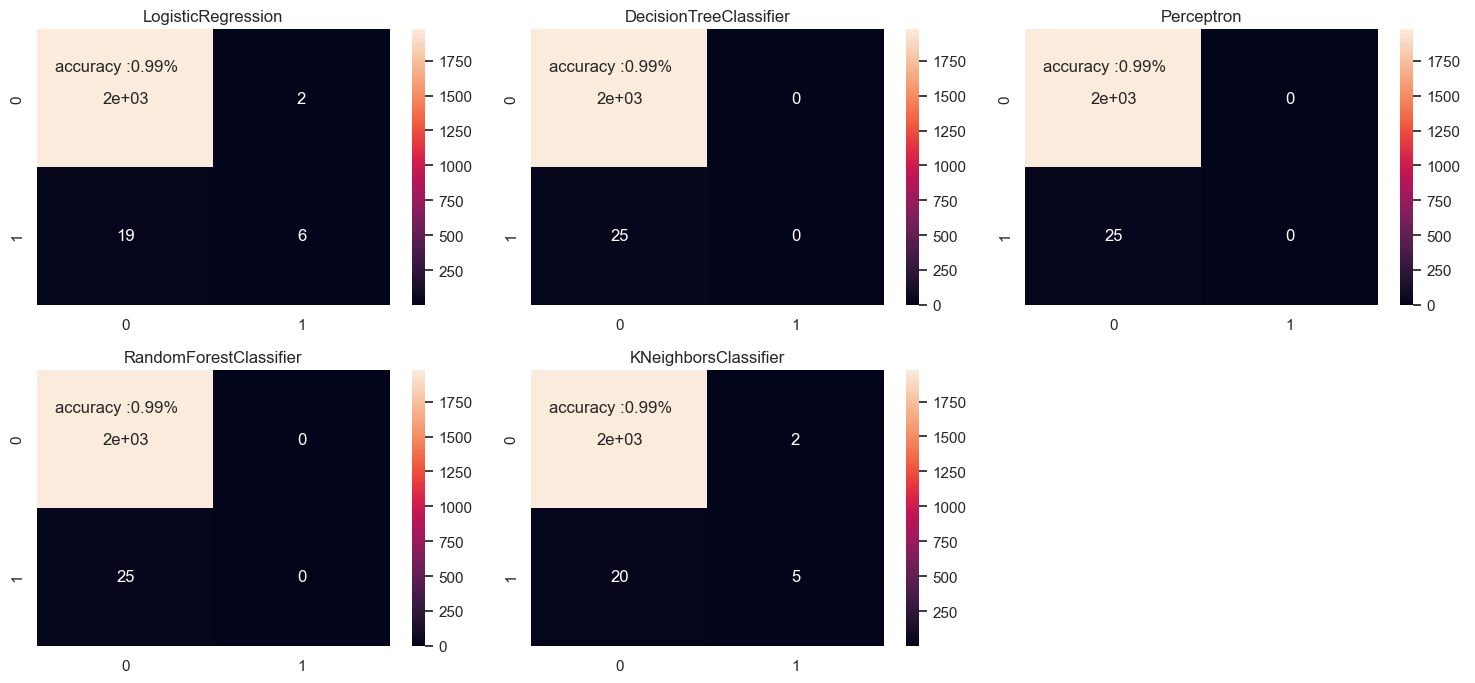

In [27]:
new_X_train=X_train[['merchant_category','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h']]
new_X_test=X_test[['merchant_category','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h']]

cols=ColumnTransformer([
    ('encode',OrdinalEncoder(),['merchant_category']),
    ('std',StandardScaler(),['foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h'])
],remainder='passthrough')

models=[LogisticRegression(max_iter=200) , DecisionTreeClassifier(max_depth=2) ,
        Perceptron(max_iter=800,random_state=43,penalty='l2'), RandomForestClassifier(max_depth=1,n_estimators=20),
        KNeighborsClassifier(n_neighbors=4,metric='euclidean')]

fig,ax=plt.subplots(2,3,figsize=(15,7)) # all figures
ax=ax.flatten()

for i , model in enumerate(models):
    pipeline=Pipeline(
    [
        ('preprocess',cols),
        ('mod',model)
    ]
    )
    pipeline.fit(new_X_train,y_train)

    y_pred=pipeline.predict(new_X_test)

    sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,ax=ax[i])
    ax[i].text(s=f"accuracy :{accuracy_score(y_test,y_pred):.2f}%",x=0.05,y=0.85,transform=ax[i].transAxes)
    ax[i].set_title(model.__class__.__name__)

ax[-1].axis('off')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.utils import resample
import numpy as np

data = np.column_stack((X[['merchant_category','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h']].values, y.values))
class_0 = data[data[:, -1] == 0]
class_1 = data[data[:, -1] == 1]

if len(class_0) < len(class_1):
    class_0_upsampled = resample(class_0,
                                 replace=True,
                                 n_samples=5000,
                                 random_state=42)
    data_balanced = np.vstack((class_0_upsampled, class_1))
else:
    class_1_upsampled = resample(
        class_1, 
        replace=True,
        n_samples=5000,
        random_state=42
    )
    data_balanced = np.vstack((class_0, class_1_upsampled))

np.random.shuffle(data_balanced)
X_resampled = data_balanced[:, :-1]
y_resampled = data_balanced[:, -1]

In [29]:
new_X_resampled=pd.DataFrame(X_resampled,columns=new_X_train.columns)
new_y_resampled=pd.DataFrame(y_resampled,columns=['is_fraud'])

In [30]:
new_X_resampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   merchant_category    14849 non-null  object
 1   foreign_transaction  14849 non-null  object
 2   location_mismatch    14849 non-null  object
 3   device_trust_score   14849 non-null  object
 4   velocity_last_24h    14849 non-null  object
dtypes: object(5)
memory usage: 580.2+ KB


In [31]:
for col in new_X_resampled.iloc[:,1:].columns:
    new_X_resampled[col]=new_X_resampled[col].astype('int16')

new_y_resampled['is_fraud']=new_y_resampled['is_fraud'].astype('int16')

In [32]:
new_y_resampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   is_fraud  14849 non-null  int16
dtypes: int16(1)
memory usage: 29.1 KB


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    new_X_resampled,y_resampled,test_size=0.2,random_state=43
)

In [34]:
y_train = np.asarray(y_train).ravel()
y_train = y_train.astype(int)
y_test = np.asarray(y_test).ravel()
y_test = y_test.astype(int)

In [35]:
X_test.shape

(2970, 5)

In [36]:
y_train.shape

(11879,)

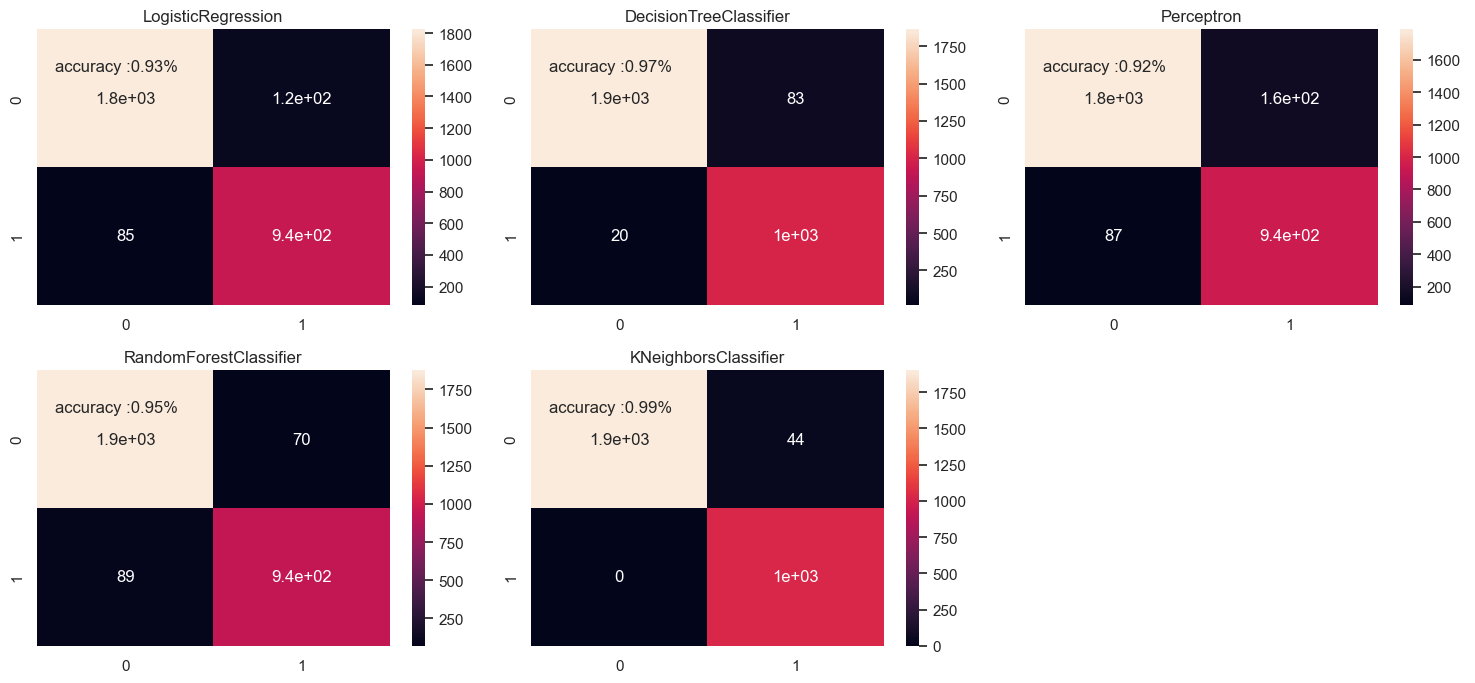

In [38]:
models=[LogisticRegression(max_iter=200) , DecisionTreeClassifier(max_depth=5) ,
        Perceptron(max_iter=800,random_state=43,penalty='l2'), RandomForestClassifier(max_depth=3,n_estimators=50),
        KNeighborsClassifier(n_neighbors=4,metric='euclidean')]

fig,ax=plt.subplots(2,3,figsize=(15,7))
ax=ax.flatten()

for i , model in enumerate(models):
    pipeline=Pipeline(
    [
        ('preprocess',cols),
        ('mod',model)
    ]
    )
    pipeline.fit(X_train,y_train)

    y_pred=pipeline.predict(X_test)

    sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,ax=ax[i])
    ax[i].text(s=f"accuracy :{accuracy_score(y_test,y_pred):.2f}%",x=0.05,y=0.85,transform=ax[i].transAxes)
    ax[i].set_title(model.__class__.__name__)

ax[-1].axis('off')
plt.tight_layout()
plt.show()

In [39]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = [
    LogisticRegression(max_iter=200),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    KNeighborsClassifier()
]

param_grids = {
    LogisticRegression: {'mod__C': [0.1, 1, 10], 'mod__solver': ['lbfgs']},
    DecisionTreeClassifier: {'mod__max_depth': [3, 5, 7], 'mod__min_samples_split': [2, 5]},
    RandomForestClassifier: {'mod__n_estimators': [50, 100], 'mod__max_depth': [3, 5]},
    KNeighborsClassifier: {'mod__n_neighbors': [3, 5, 7], 'mod__metric': ['euclidean', 'manhattan']}
}

best_results = []

for model in models:
    pipeline = Pipeline([
        ('preprocess', cols),
        ('mod', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid=param_grids[type(model)],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print(f"Model: {type(model).__name__}")
    print(f"Base params:", grid.best_params_)
    print("Base CV score:", grid.best_score_)
    print()

    best_results.append((type(model).__name__, grid.best_score_, grid.best_params_))

Model: LogisticRegression
Base params: {'mod__C': 1, 'mod__solver': 'lbfgs'}
Base CV score: 0.9228892078681552

Model: DecisionTreeClassifier
Base params: {'mod__max_depth': 7, 'mod__min_samples_split': 5}
Base CV score: 0.9709573276625909

Model: RandomForestClassifier
Base params: {'mod__max_depth': 5, 'mod__n_estimators': 50}
Base CV score: 0.9608553606237816

Model: KNeighborsClassifier
Base params: {'mod__metric': 'manhattan', 'mod__n_neighbors': 3}
Base CV score: 0.9815645933014354

